Loading models and data...
Processing pipeline stages...
Generating graphic...
Saved as pipeline_breakdown_comprehensive.png!


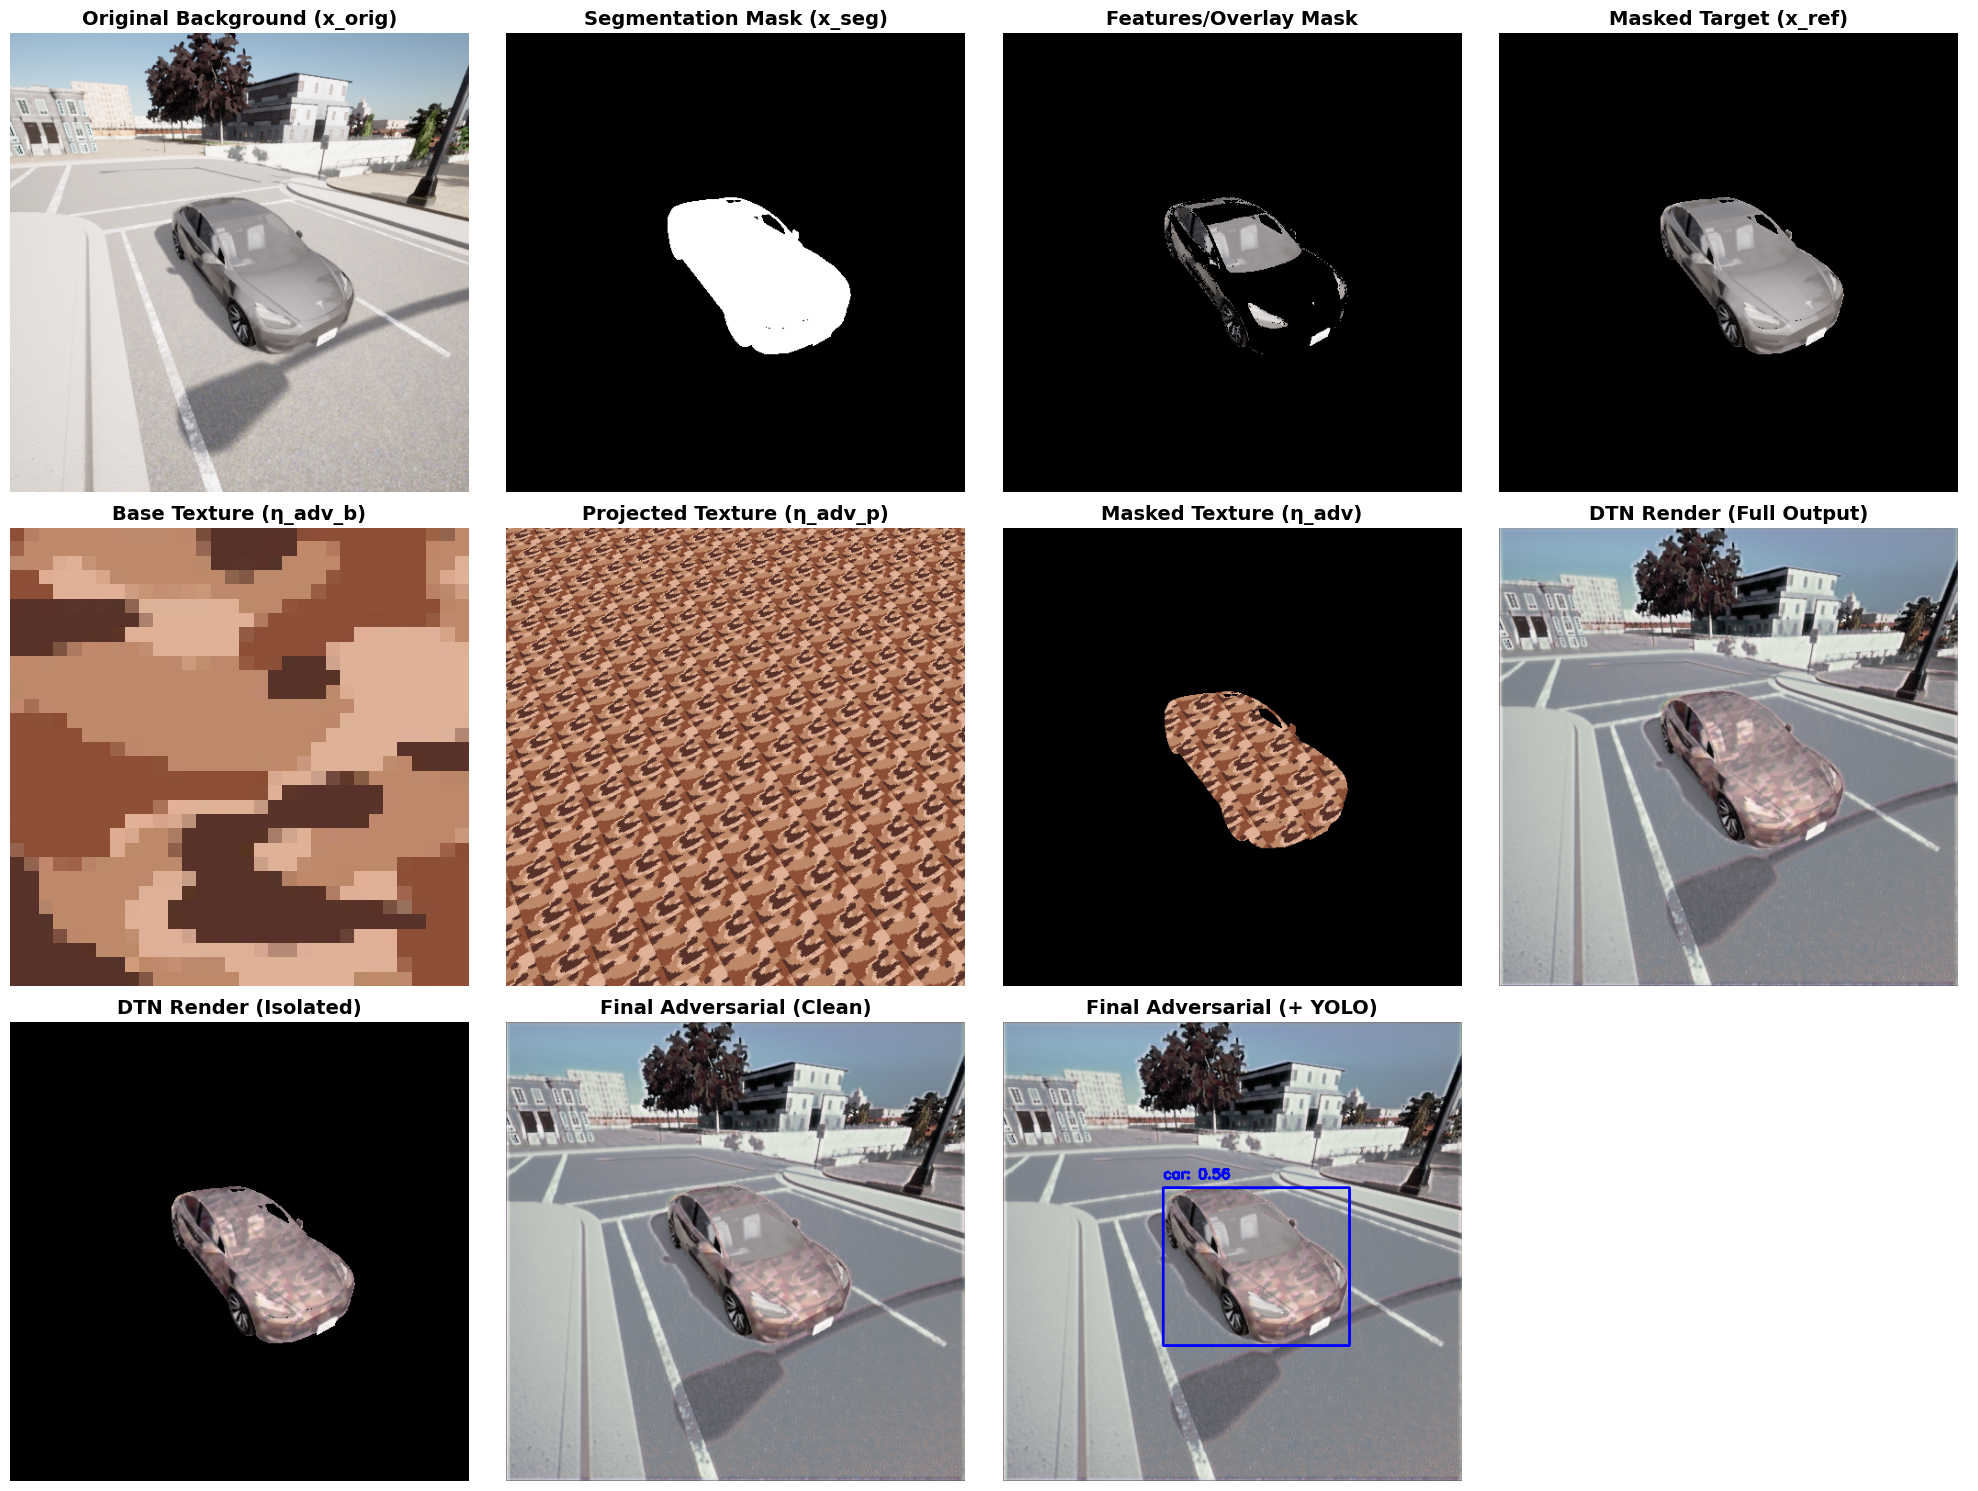

In [4]:
import tensorflow as tf
import numpy as np
import os
import cv2
from glob import glob
import matplotlib.pyplot as plt
import pandas as pd

# ========== CONFIGURATION ==========
DATASET_FOLDER    = 'sample_dataset'
METADATA_CSV      = os.path.join(DATASET_FOLDER, 'metadata.csv')
SAMPLE_IDX        = 2468

MODEL_PATH_RENDERER = 'models/k3_100epch_wo_custom_loss_model.h5'
MODEL_PATH_YOLO     = 'yolov8n_saved_model'

IMG_SIZE          = (500, 500)
YOLO_SIZE         = (640, 640)
TEX_RES           = 32
TEX_UPSCALE_RES   = 256
INITIAL_TEX_PATH  = 'textures/camo_muddy.png'

# Minimal classes dict for drawing YOLO bounding boxes
CLASSES = {2: 'car', 5: 'bus', 7: 'truck'} 

# ========== HELPER FUNCTIONS ==========

def load_image_for_style(path):
    img = tf.image.convert_image_dtype(tf.image.decode_png(tf.io.read_file(path), channels=3), tf.float32)
    return tf.expand_dims(tf.image.resize(img, [TEX_UPSCALE_RES, TEX_UPSCALE_RES]), 0)

def load_dataset_sample(idx):
    df_meta = pd.read_csv(METADATA_CSV)
    row = df_meta.iloc[idx]
    base_name = str(row['filename']).zfill(5)

    def load_img(subfolder, ext):
        path = os.path.join(DATASET_FOLDER, subfolder, f"{base_name}{ext}")
        if not os.path.exists(path):
            path = glob(os.path.join(DATASET_FOLDER, subfolder, f"{base_name}.*"))[0]
        img = tf.image.decode_image(tf.io.read_file(path), channels=3)
        return tf.image.resize(tf.image.convert_image_dtype(img, tf.float32), IMG_SIZE)

    ref     = load_img('reference', '.png')
    mask    = load_img('masks',     '.png')
    overlay = load_img('overlays',  '.png')
    trans   = np.array([row['distance'], row['pitch'], row['yaw']], dtype=np.float32)
    return ref, mask, overlay, trans

def calc_transforms(pitch, yaw):
    yaw_diff   = ((yaw + 45.0) % 90.0) - 45.0
    cond_front = tf.logical_and(yaw > 145.0, yaw < 215.0)

    p = tf.where(cond_front, -pitch, pitch)
    y = tf.where(cond_front, -yaw_diff, 0.0)
    r = tf.where(cond_front, 0.0, -yaw_diff)

    p = tf.where(pitch < 15.0, pitch,  p);  y = tf.where(pitch < 15.0, 0.0,       y);  r = tf.where(pitch < 15.0, -yaw_diff, r)
    p = tf.where(pitch > 35.0, -pitch, p);  y = tf.where(pitch > 35.0, -yaw_diff, y);  r = tf.where(pitch > 35.0, 0.0,       r)
    return p, y, r

def get_rotation_matrix(pitch, yaw, roll):
    s = np.pi / 180.0
    p, y, r = pitch * s, yaw * s, roll * s
    Rp = tf.stack([[1., 0., 0.], [0., tf.cos(p), -tf.sin(p)], [0., tf.sin(p), tf.cos(p)]])
    Rr = tf.stack([[tf.cos(r), 0., tf.sin(r)], [0., 1., 0.], [-tf.sin(r), 0., tf.cos(r)]])
    Ry = tf.stack([[tf.cos(y), -tf.sin(y), 0.], [tf.sin(y), tf.cos(y), 0.], [0., 0., 1.]])
    return tf.matmul(Rp, tf.matmul(Rr, Ry))

@tf.function
def render_texture(texture, pitch, yaw, roll, distance, uv_scale=100.0, shift_u=0.0, shift_v=0.0):
    out_h, out_w = IMG_SIZE
    f  = 500.0
    high_res_tex = tf.image.resize(texture, [TEX_UPSCALE_RES, TEX_UPSCALE_RES], method='nearest')
    R            = get_rotation_matrix(pitch, yaw, roll)
    plane_normal = R[:, 2]
    plane_point  = plane_normal * (distance * 100.0)

    grid_x, grid_y = tf.meshgrid(tf.range(out_w), tf.range(out_h))
    ray_dir    = tf.stack([tf.cast(grid_x, tf.float32) - out_w/2.0,
                           tf.cast(grid_y, tf.float32) - out_h/2.0,
                           tf.ones([out_h, out_w]) * f], axis=-1)
    camera_pos = tf.constant([0.0, 0.0, -f])

    denom = tf.tensordot(ray_dir, plane_normal, axes=1)
    denom = tf.where(tf.abs(denom) < 1e-5, 1e-5, denom)
    t     = tf.tensordot(plane_point - camera_pos, plane_normal, axes=1) / denom

    hit_point = camera_pos + ray_dir * tf.expand_dims(t, -1)
    p_local   = tf.reshape(tf.matmul(tf.reshape(hit_point - plane_point, [-1, 3]), R), [out_h, out_w, 3])

    u = tf.math.floormod(p_local[:, :, 0] / uv_scale + shift_u, 1.0)
    v = tf.math.floormod(p_local[:, :, 1] / uv_scale + shift_v, 1.0)

    tex_h = tf.cast(tf.shape(high_res_tex)[0], tf.float32)
    tex_w = tf.cast(tf.shape(high_res_tex)[1], tf.float32)

    x, y_ = u * (tex_w - 1.0), v * (tex_h - 1.0)
    x  = tf.clip_by_value(x,  0.0, tex_w - 1.001)
    y_ = tf.clip_by_value(y_, 0.0, tex_h - 1.001)
    x0, y0 = tf.cast(tf.floor(x), tf.int32), tf.cast(tf.floor(y_), tf.int32)
    x1, y1 = x0 + 1, y0 + 1
    Ia = tf.gather_nd(high_res_tex, tf.stack([y0, x0], axis=-1))
    Ib = tf.gather_nd(high_res_tex, tf.stack([y1, x0], axis=-1))
    Ic = tf.gather_nd(high_res_tex, tf.stack([y0, x1], axis=-1))
    Id = tf.gather_nd(high_res_tex, tf.stack([y1, x1], axis=-1))
    wa = tf.expand_dims((tf.cast(x1, tf.float32) - x)  * (tf.cast(y1, tf.float32) - y_), -1)
    wb = tf.expand_dims((tf.cast(x1, tf.float32) - x)  * (y_ - tf.cast(y0, tf.float32)), -1)
    wc = tf.expand_dims((x - tf.cast(x0, tf.float32))  * (tf.cast(y1, tf.float32) - y_), -1)
    wd = tf.expand_dims((x - tf.cast(x0, tf.float32))  * (y_ - tf.cast(y0, tf.float32)), -1)
    output = tf.add_n([wa*Ia, wb*Ib, wc*Ic, wd*Id])

    return tf.where(tf.expand_dims(t > 0.0, -1), output, tf.zeros_like(output))

def draw_yolo_results(image_tf, yolo_output, conf_thresh=0.25):
    img    = (image_tf.numpy() * 255).astype(np.uint8).copy()
    output = np.transpose(yolo_output.numpy()[0])
    scale  = [IMG_SIZE[1] / YOLO_SIZE[1], IMG_SIZE[0] / YOLO_SIZE[0]] * 2

    boxes, confs, class_ids = [], [], []
    for row in output:
        cls_id = np.argmax(row[4:])
        score  = row[4:][cls_id]
        if score > conf_thresh:
            cx, cy, w, h = row[:4] * scale
            boxes.append([int(cx - w/2), int(cy - h/2), int(w), int(h)])
            confs.append(float(score));  class_ids.append(cls_id)

    indices = cv2.dnn.NMSBoxes(boxes, confs, conf_thresh, 0.45)
    if len(indices) > 0:
        for i in indices.flatten():
            bx, by, bw, bh = boxes[i]
            cv2.rectangle(img, (bx, by), (bx+bw, by+bh), (0, 0, 255), 2)
            cv2.putText(img, f"{CLASSES.get(class_ids[i], 'obj')}: {confs[i]:.2f}", (bx, by-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
    return img

# ========== MAIN PIPELINE EXECUTION ==========

if __name__ == '__main__':
    print("Loading models and data...")
    
    renderer_model = tf.keras.models.load_model(MODEL_PATH_RENDERER, compile=False)
    yolo_loaded    = tf.saved_model.load(MODEL_PATH_YOLO)
    yolo_infer     = yolo_loaded.signatures['serving_default']

    initial_tex = load_image_for_style(INITIAL_TEX_PATH)
    texture     = tf.image.resize(initial_tex, [TEX_RES, TEX_RES])[0]

    ref, mask, overlay, trans = load_dataset_sample(SAMPLE_IDX)
    trans_tf = tf.constant(trans[:3].astype(np.float32))
    
    print("Processing pipeline stages...")
    
    p, y, r = calc_transforms(trans_tf[1], trans_tf[2])
    dist    = trans_tf[0]
    
    # Extract components mapped directly to your architecture diagram:
    eta_adv_b = tf.clip_by_value(texture, 0.0, 1.0).numpy()
    eta_adv_p = render_texture(texture, p, y, r, dist)
    x_orig    = ref.numpy()
    x_seg     = mask.numpy()
    x_overlay = overlay.numpy()
    
    x_ref   = tf.where(tf.reduce_max(mask, axis=-1, keepdims=True) > 0.1, ref, tf.zeros_like(ref))
    eta_adv = tf.where(tf.reduce_max(mask, axis=-1, keepdims=True) > 0.1, eta_adv_p, tf.zeros_like(eta_adv_p))
    dtn_out = renderer_model([tf.expand_dims(ref, 0), tf.expand_dims(eta_adv, 0)], training=False)[0]
    
    # ISOLATE DTN OUTPUT (Prediction without background)
    dtn_isolated = tf.where(tf.reduce_max(mask, axis=-1, keepdims=True) > 0.1, dtn_out, tf.zeros_like(dtn_out))

    x_adv   = tf.where(tf.reduce_max(overlay, axis=-1, keepdims=True) > 0.05, ref, dtn_out)
    
    yolo_final_out  = yolo_infer(images=tf.image.resize(tf.expand_dims(x_adv, 0), YOLO_SIZE))['output_0']
    x_adv_with_bbox = draw_yolo_results(x_adv, yolo_final_out)

    # 5. Plotting (Now a 3x4 Grid for 11 plots)
    print("Generating graphic...")
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()
    
    # Row 1: Scene Inputs
    axes[0].imshow(x_orig)
    axes[0].set_title("Original Background (x_orig)", fontsize=14, fontweight='bold')
    
    axes[1].imshow(x_seg)
    axes[1].set_title("Segmentation Mask (x_seg)", fontsize=14, fontweight='bold')

    axes[2].imshow(x_overlay)
    axes[2].set_title("Features/Overlay Mask", fontsize=14, fontweight='bold')

    axes[3].imshow(x_ref.numpy())
    axes[3].set_title("Masked Target (x_ref)", fontsize=14, fontweight='bold')
    
    # Row 2: Texture Projections & Raw Render
    axes[4].imshow(eta_adv_b)
    axes[4].set_title("Base Texture (\u03B7_adv_b)", fontsize=14, fontweight='bold')
    
    axes[5].imshow(eta_adv_p.numpy())
    axes[5].set_title("Projected Texture (\u03B7_adv_p)", fontsize=14, fontweight='bold')

    axes[6].imshow(eta_adv.numpy())
    axes[6].set_title("Masked Texture (\u03B7_adv)", fontsize=14, fontweight='bold')

    axes[7].imshow(dtn_out.numpy())
    axes[7].set_title("DTN Render (Full Output)", fontsize=14, fontweight='bold')
    
    # Row 3: Final Computations & Outputs
    axes[8].imshow(dtn_isolated.numpy())
    axes[8].set_title("DTN Render (Isolated)", fontsize=14, fontweight='bold')
    
    axes[9].imshow(x_adv.numpy())
    axes[9].set_title("Final Adversarial (Clean)", fontsize=14, fontweight='bold')
    
    axes[10].imshow(x_adv_with_bbox)
    axes[10].set_title("Final Adversarial (+ YOLO)", fontsize=14, fontweight='bold')
    
    # Hide the 12th empty subplot
    axes[11].axis('off')

    for ax in axes[:11]:
        ax.axis('off')
        
    plt.tight_layout()
    plt.savefig('pipeline_breakdown_comprehensive.png', dpi=300, bbox_inches='tight')
    print("Saved as pipeline_breakdown_comprehensive.png!")
    plt.show()